# 03 — Feature Engineering

Prepara o dataset para modelagem. Features construídas:
- **Lags de preço:** t-1, t-2, t-3 — captura autocorrelação
- **Retorno mensal:** variação % m/m defasada
- **Features sazonais:** mês, trimestre, flag de colheita
- **Câmbio defasado:** USD/BRL com lag de 1 e 3 meses
- **Preço real:** deflacionado pelo IPCA acumulado
- **Componente sazonal:** extraído via STL

Período: jul/2016 → último mês com IPCA divulgado (cobertura completa de todas as fontes).  
Output: `data/processed/features_soja.parquet` e `data/processed/features_milho.parquet`

In [34]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 4)

RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../reports/figures')
PROC_DIR.mkdir(parents=True, exist_ok=True)

---
## 0. Atualiza bcb_macro com período completo

In [35]:
# Reconstrói bcb_macro a partir dos parquets individuais atualizados
df_usd      = pd.read_parquet(RAW_DIR / 'bcb_usd_brl.parquet')
df_selic    = pd.read_parquet(RAW_DIR / 'bcb_selic.parquet')
df_ipca_raw = pd.read_parquet(RAW_DIR / 'bcb_ipca.parquet')

df_macro_novo = df_usd.merge(df_selic, on='data', how='outer')
df_macro_novo = df_macro_novo.merge(df_ipca_raw, on='data', how='outer')
df_macro_novo = df_macro_novo.sort_values('data').reset_index(drop=True)
df_macro_novo.to_parquet(RAW_DIR / 'bcb_macro.parquet', index=False)

print('macro:', df_macro_novo['data'].min().date(), '→', df_macro_novo['data'].max().date())
print(df_macro_novo.shape)

macro: 2016-07-01 → 2026-06-26
(2556, 4)


---
## 1. Carregamento e alinhamento

In [36]:
df_soja  = pd.read_parquet(RAW_DIR / 'cepea_soja.parquet')
df_milho = pd.read_parquet(RAW_DIR / 'cepea_milho.parquet')
df_macro = pd.read_parquet(RAW_DIR / 'bcb_macro.parquet')

# Macro diário → mensal (último valor do mês), normaliza para primeiro dia
df_macro = (
    df_macro.set_index('data')
    .resample('ME').last()
    .reset_index()
)
df_macro['data'] = df_macro['data'].dt.to_period('M').dt.to_timestamp()

# IPCA % ao mês → índice acumulado (base = primeiro mês disponível)
df_ipca = pd.read_parquet(RAW_DIR / 'bcb_ipca.parquet').copy()
df_ipca['data'] = pd.to_datetime(df_ipca['data']).dt.to_period('M').dt.to_timestamp()
df_ipca = df_ipca.sort_values('data').reset_index(drop=True)
df_ipca['ipca_acum'] = (1 + df_ipca['ipca'] / 100).cumprod()
base = df_ipca['ipca_acum'].iloc[0]
df_ipca['ipca_acum'] = df_ipca['ipca_acum'] / base * 100

print('soja: ', df_soja.shape)
print('milho:', df_milho.shape)
print('macro:', df_macro.shape)
print('ipca: ', df_ipca.shape)

soja:  (126, 4)
milho: (126, 4)
macro: (120, 4)
ipca:  (119, 3)


---
## 2. Feature engineering

In [37]:
COLHEITA = {
    'soja':  [3, 4, 5],
    'milho': [2, 3, 7, 8],
}


def build_features(df_cepea, df_macro, df_ipca, commodity):
    df = df_cepea[['data', 'preco_rs']].copy()
    df = df.sort_values('data').reset_index(drop=True)

    # Lags de preço
    for lag in [1, 2, 3]:
        df[f'preco_lag{lag}'] = df['preco_rs'].shift(lag)

    # Retorno mensal defasado
    df['retorno_mm'] = df['preco_rs'].pct_change() * 100
    df['retorno_lag1'] = df['retorno_mm'].shift(1)

    # Features sazonais
    df['mes'] = df['data'].dt.month
    df['trimestre'] = df['data'].dt.quarter
    df['colheita'] = df['mes'].isin(COLHEITA[commodity]).astype(int)

    # Câmbio com lag de 1 e 3 meses
    df = df.merge(df_macro[['data', 'usd_brl']], on='data', how='left')
    df['cambio_lag1'] = df['usd_brl'].shift(1)
    df['cambio_lag3'] = df['usd_brl'].shift(3)

    # Preço real deflacionado pelo IPCA
    df = df.merge(df_ipca[['data', 'ipca_acum']], on='data', how='left')
    df['preco_real'] = df['preco_rs'] / df['ipca_acum'] * 100

    # Componente sazonal via STL
    serie = df.set_index('data')['preco_rs']
    stl = STL(serie, period=12, robust=True).fit()
    df['sazonalidade_stl'] = stl.seasonal.values
    df['tendencia_stl'] = stl.trend.values

    # Corta para jul/2016 — cobertura completa do BCB
    df = df[df['data'] >= '2016-07-01'].reset_index(drop=True)

    # Remove lags incompletos, meses sem IPCA e primeiros meses sem câmbio defasado
    drop_cols = ['preco_lag1', 'preco_lag2', 'preco_lag3', 'retorno_lag1', 'preco_real', 'cambio_lag1', 'cambio_lag3']
    df = df.dropna(subset=drop_cols).reset_index(drop=True)

    df['commodity'] = commodity
    return df


datasets = {}
for commodity, df_cepea in [('soja', df_soja), ('milho', df_milho)]:
    df_feat = build_features(df_cepea, df_macro, df_ipca, commodity)
    datasets[commodity] = df_feat
    df_feat.to_parquet(PROC_DIR / f'features_{commodity}.parquet', index=False)
    print(f'{commodity}: {df_feat.shape} | {df_feat["data"].min().date()} → {df_feat["data"].max().date()}')
    display(df_feat.head(3))

soja: (116, 18) | 2016-10-01 → 2026-05-01


,data,preco_rs,preco_lag1,preco_lag2,preco_lag3,retorno_mm,retorno_lag1,mes,trimestre,colheita,usd_brl,cambio_lag1,cambio_lag3,ipca_acum,preco_real,sazonalidade_stl,tendencia_stl,commodity
0,2016-10-01,73.93,76.14,77.57,82.84,-2.902548,-1.843496,10,4,0,3.1811,3.2462,3.2390,100.781705,73.356568,-0.076479,74.259045,soja
1,2016-11-01,74.90,73.93,76.14,77.57,1.312052,-2.902548,11,4,0,3.3967,3.1811,3.2403,100.963112,74.185510,1.753821,73.356152,soja
2,2016-12-01,74.71,74.90,73.93,76.14,-0.253672,1.312052,12,4,0,3.2591,3.3967,3.2462,101.266001,73.775995,1.305791,72.357858,soja


milho: (116, 18) | 2016-10-01 → 2026-05-01


,data,preco_rs,preco_lag1,preco_lag2,preco_lag3,retorno_mm,retorno_lag1,mes,trimestre,colheita,usd_brl,cambio_lag1,cambio_lag3,ipca_acum,preco_real,sazonalidade_stl,tendencia_stl,commodity
0,2016-10-01,42.12,41.91,45.43,44.42,0.501074,-7.748184,10,4,0,3.1811,3.2462,3.2390,100.781705,41.793300,-0.538570,40.902819,milho
1,2016-11-01,38.77,42.12,41.91,45.43,-7.953466,0.501074,11,4,0,3.3967,3.1811,3.2403,100.963112,38.400163,-1.101944,39.810437,milho
2,2016-12-01,38.29,38.77,42.12,41.91,-1.238071,-7.953466,12,4,0,3.2591,3.3967,3.2462,101.266001,37.811308,-0.938717,38.651405,milho


---
## 3. Preço nominal vs real

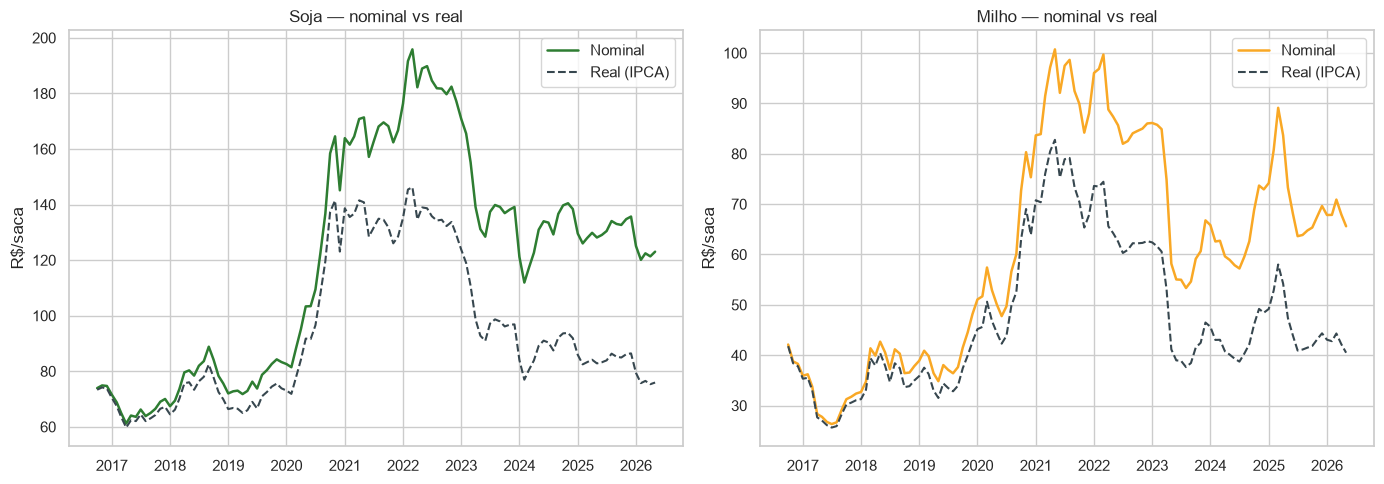

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    df = datasets[commodity]
    ax.plot(df['data'], df['preco_rs'],   color=cor,       linewidth=1.8, label='Nominal')
    ax.plot(df['data'], df['preco_real'], color='#37474f', linewidth=1.5, linestyle='--', label='Real (IPCA)')
    ax.set_title(f'{commodity.capitalize()} — nominal vs real')
    ax.set_ylabel('R$/saca')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'nominal_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Correlação das features com o preço alvo

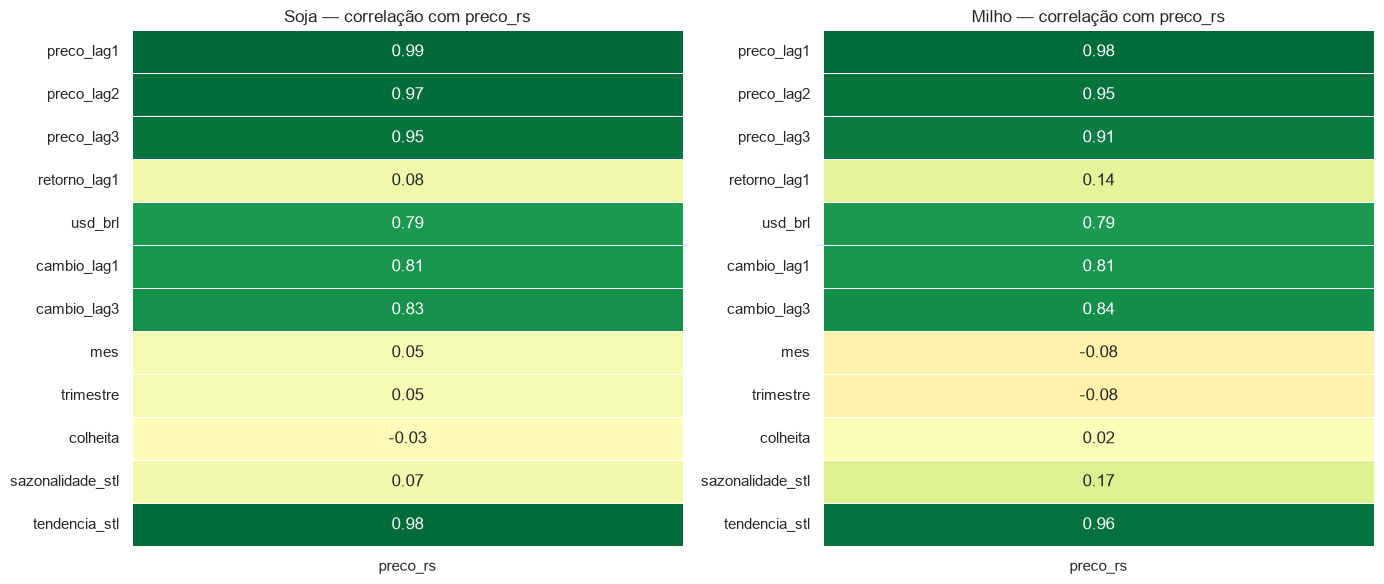

In [39]:
FEATURES = [
    'preco_rs', 'preco_lag1', 'preco_lag2', 'preco_lag3',
    'retorno_lag1', 'usd_brl', 'cambio_lag1', 'cambio_lag3',
    'mes', 'trimestre', 'colheita', 'sazonalidade_stl', 'tendencia_stl',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, commodity in zip(axes, ['soja', 'milho']):
    corr = datasets[commodity][FEATURES].corr()[['preco_rs']].drop('preco_rs')
    sns.heatmap(
        corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
        center=0, vmin=-1, vmax=1, linewidths=0.5, cbar=False,
    )
    ax.set_title(f'{commodity.capitalize()} — correlação com preco_rs')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / 'correlacao_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Checagem final

In [40]:
for commodity, df in datasets.items():
    print(f'\n{commodity.upper()}')
    print(f'  Shape: {df.shape}')
    print(f'  Período: {df["data"].min().date()} → {df["data"].max().date()}')
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print('  Nulos: nenhum' if nulos.empty else f'  Nulos:\n{nulos.to_string()}')

print('\ndata/processed/:')
for f in sorted(PROC_DIR.glob('*.parquet')):
    print(f'  {f.name:<40} {len(pd.read_parquet(f)):>6} registros')

print('\nFeature engineering concluido. Proximo passo: 04_modelo_prophet.ipynb')


SOJA
  Shape: (116, 18)
  Período: 2016-10-01 → 2026-05-01
  Nulos: nenhum

MILHO
  Shape: (116, 18)
  Período: 2016-10-01 → 2026-05-01
  Nulos: nenhum

data/processed/:
  features_milho.parquet                      116 registros
  features_soja.parquet                       116 registros

Feature engineering concluido. Proximo passo: 04_modelo_prophet.ipynb
